# Polynomial Regression:

- Polynomial regression is a method for modeling curvilinear relationships between variables by adding polynomial terms (like x^2, x^3) of the independent variable to a linear regression model.
- It allows the model to fit curves to data that doesn't fit a straight line.
- While it creates a non-linear relationship between the original independent and dependent variables, the model itself remains linear in terms of its parameters, allowing it to be solved using familiar linear regression techniques like ordinary least squares.


- How it Works:
    - Extend the Linear Model: A standard linear regression has the form y = β₀ + β₁x. Polynomial regression extends this by adding higher-degree terms of the independent variable x, such as:
y = β₀ + β₁x + β₂x² + β₃x³ + ... + βₙxⁿ.

    - Non-Linear Data: This extension allows the model to fit curved lines — for example, U-shaped or S-shaped patterns — which a simple straight line (linear regression) cannot capture.

    - Linear in Parameters: Even though the relationship between x and y is non-linear, the model is still linear in its coefficients (β₀, β₁, …, βₙ). You can treat each power of x (x, x², x³, etc.) as a separate independent variable.

    - Fit with Techniques: Since the model remains linear in its parameters, you can still use standard linear regression methods to find the best coefficient values (the βs) that fit the data.
 
- When to Use It:
    - Non-Linear Data: When the relationship between your dependent and independent variables is curved, not a straight line.
    - Complex Relationships: To capture more complex patterns that simple linear regression cannot. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

#### Example 1 (Synthetic Data):

In [2]:
# Creating X (Features) and y (Target) Variables:

X = 6 * np.random.rand(200,1) - 3

# y = 0.8X^2 + 0.9X + 2 + random noise
y = 0.8*(X**2) + 0.9 * X + 2 + np.random.randn(200,1)

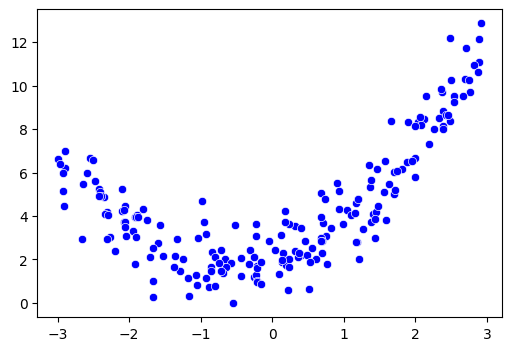

In [3]:
# Plotting X and y:

plt.figure(figsize = (6,4))
sns.scatterplot(x= X.ravel(), y= y.ravel(), color= 'blue')
plt.show()

In [4]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [5]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160, 1)
(40, 1)


##### 1) Simple Linear Regression Model:

In [7]:
lr1 = LinearRegression()
lr1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Predictions using Model:

y_pred = lr1.predict(X_test)

In [9]:
# Model Evaluation:

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

RMSE: 2.412563434722982
R2-Score: 0.1775308844270309


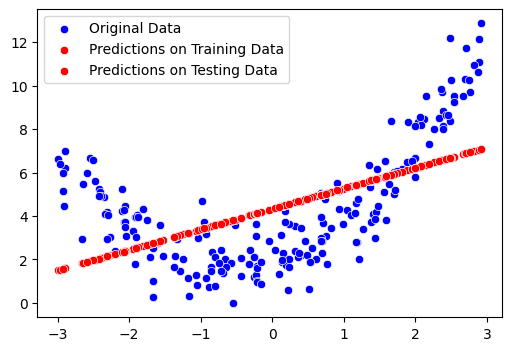

In [10]:
# Plotting Original Data (Full Data) vs Model Predictions:

plt.figure(figsize = (6,4))
sns.scatterplot(x= X.ravel(), y= y.ravel(), color= 'blue', label= 'Original Data')
sns.scatterplot(x= X_train.ravel(), y= lr1.predict(X_train).ravel(), color= 'red', label= 'Predictions on Training Data')
sns.scatterplot(x= X_test.ravel(), y= lr1.predict(X_test).ravel(), color= 'red', label= 'Predictions on Testing Data')
plt.show()

##### 2) Polynomial Regression Model:

**From Preprocessing, import PolynomialFeatures, which will help us transform our original data set by adding polynomial features**

We will go from the equation in the form (shown here as if we only had one x feature):

$$\hat{y} = \beta_0 + \beta_1x_1 + \epsilon $$

and create more features from the original x feature for some *d* degree of polynomial.

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_1x^2_1 +  ... + \beta_dx^d_1 + \epsilon$$

Then we can call the linear regression model on it, since in reality, we're just treating these new polynomial features x^2, x^3, ... x^d as new features. Obviously we need to be careful about choosing the correct value of *d* , the degree of the model. Our metric results on the test set will help us with this!

**The other thing to note here is we have multiple X features, not just a single one as in the formula above, so in reality, the PolynomialFeatures will also take *interaction* terms into account for example, if an input sample is two dimensional and of the form [a, b], the degree-2 polynomial features are [1, a, b, a^2, ab, b^2].**

In [11]:
# Creating Plynomial Features with Degree 2:

poly_features = PolynomialFeatures(degree= 2, include_bias= True)

In [12]:
# Turning Training and Test Data into Polynomial Features:

X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [13]:
print(X_train[0])
print(X_train_poly[0])

[0.61175813]
[1.         0.61175813 0.37424802]


In [14]:
# Polynomial Regression Model:

lr2 = LinearRegression()
lr2.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
# Predictions using Model:

y_pred = lr2.predict(X_test_poly)

In [16]:
# Model Evaluation:

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

RMSE: 1.0365482647876938
R2-Score: 0.8481757396149896


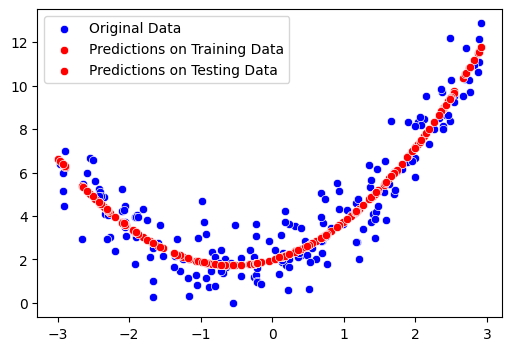

In [17]:
# Plotting Original Data (Full Data) vs Model Predictions:

plt.figure(figsize = (6,4))
sns.scatterplot(x= X.ravel(), y= y.ravel(), color= 'blue', label= 'Original Data')
sns.scatterplot(x= X_train.ravel(), y= lr2.predict(X_train_poly).ravel(), color= 'red', label= 'Predictions on Training Data')
sns.scatterplot(x= X_test.ravel(), y= lr2.predict(X_test_poly).ravel(), color= 'red', label= 'Predictions on Testing Data')
plt.show()

In [46]:
# Model Coefficients:
print(lr2.coef_)

[[0.         0.92730112 0.83187917]]


- Original Equation for y to Create the Data was:
    - y = 0.8X^2 + 0.9X + 2 + random noise
- According to Model Coefficients:
    - y = 0.83X^2 + 0.93X + 0

#### Example 2:

In [18]:
df = pd.read_csv('Advertising.csv')

In [19]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [20]:
df = df.drop('Unnamed: 0', axis= 1)

In [21]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [23]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [24]:
# Separating Features and Target:

X = df.drop('sales', axis= 1)
y = df['sales']

In [25]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [ ]:
# Scaling Features:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### 1) Linear Regression Model:

In [30]:
# Linear Regression Model:

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
# Predictions Using Model:

y_pred = lr.predict(X_test)

In [32]:
# Model Evaluation:

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

RMSE: 1.78159966153345
R2-Score: 0.899438024100912


##### 2) Polynomial Regression Model:

In [34]:
# Polynomial Features:

poly_features = PolynomialFeatures(degree= 2, include_bias= False)

In [35]:
# Converting Original Features into Polynomial Features:

X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [36]:
print(X_train_poly.shape)
print(X_test_poly.shape)

(160, 9)
(40, 9)


Note: We had 3 Features in Original Data.

We gave degree = 2 in converter.

Suppose, our original data had features: a, b, c

Polynomial Converter with Degree= 2 will covert these three features in:

bias, a, b, c, ab, bc, ac, a^2, b^2, c^2.

We gave include_bias= False while creating converter.

That's why we got 9 features.

In [37]:
# Polynomail Regression Model:

plr = LinearRegression()
plr.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
# Predictions Using Model:

y_pred = plr.predict(X_test_poly)

In [39]:
# Model Evaluation:

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

RMSE: 0.6425809120553632
R2-Score: 0.9869181490609604


##### 3) Chosing Degrees for Polynomial Model:

Adjusting Parameters:

- Are we satisfied with this performance? Perhaps a higher order would improve performance even more! But how high is too high? It is now up to us to possibly go back and adjust our model and parameters, let's explore higher order Polynomials in a loop and plot out their error.

- Let's use a for loop to do the following:

1. Create different order polynomial X data
2. Split that polynomial data for train/test
3. Fit on the training data
4. Report back the metrics on *both* the train and test results
5. Plot these results and explore overfitting

In [41]:
# List for Storing Training RMSE of Each Model
training_rmse = []

# List for Storing Testing RMSE of Each Model
testing_rmse = []

for degrees in range(1,11):
    
    # Creting Polynomial Converter:
    poly_feat = PolynomialFeatures(degree= degrees, include_bias= False)
    
    # Converting Data into Polynomial Features:
    X_poly = poly_feat.fit_transform(X)
    
    # Train Test Split:
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size= 0.2, random_state= 42)
    
    # Polynomial Regression Model:
    pl_model = LinearRegression()
    pl_model.fit(X_train, y_train)
    
    # Predicting For Train and Test Data:
    train_pred = pl_model.predict(X_train)
    test_pred = pl_model.predict(X_test)
    
    # Calculating RMSE for Training and Testing Predictions
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Appending Errors to Corresponding Lists
    training_rmse.append(train_rmse)
    testing_rmse.append(test_rmse)

In [42]:
print(training_rmse)

[1.644727765644337, 0.6003304710491733, 0.46482379884798114, 0.36841268311155423, 0.25049491338034163, 0.259626808957284, 0.3153140628623415, 0.40445550913842515, 0.6278934301992566, 0.799574155118322]


In [43]:
print(testing_rmse)

[1.78159966153345, 0.6425809120553669, 0.5427415675079849, 0.7860986812509142, 8.746459132515911, 29.089756595076828, 74.91494571403811, 1595.2233474902214, 22265.51532725034, 20680.91009595858]


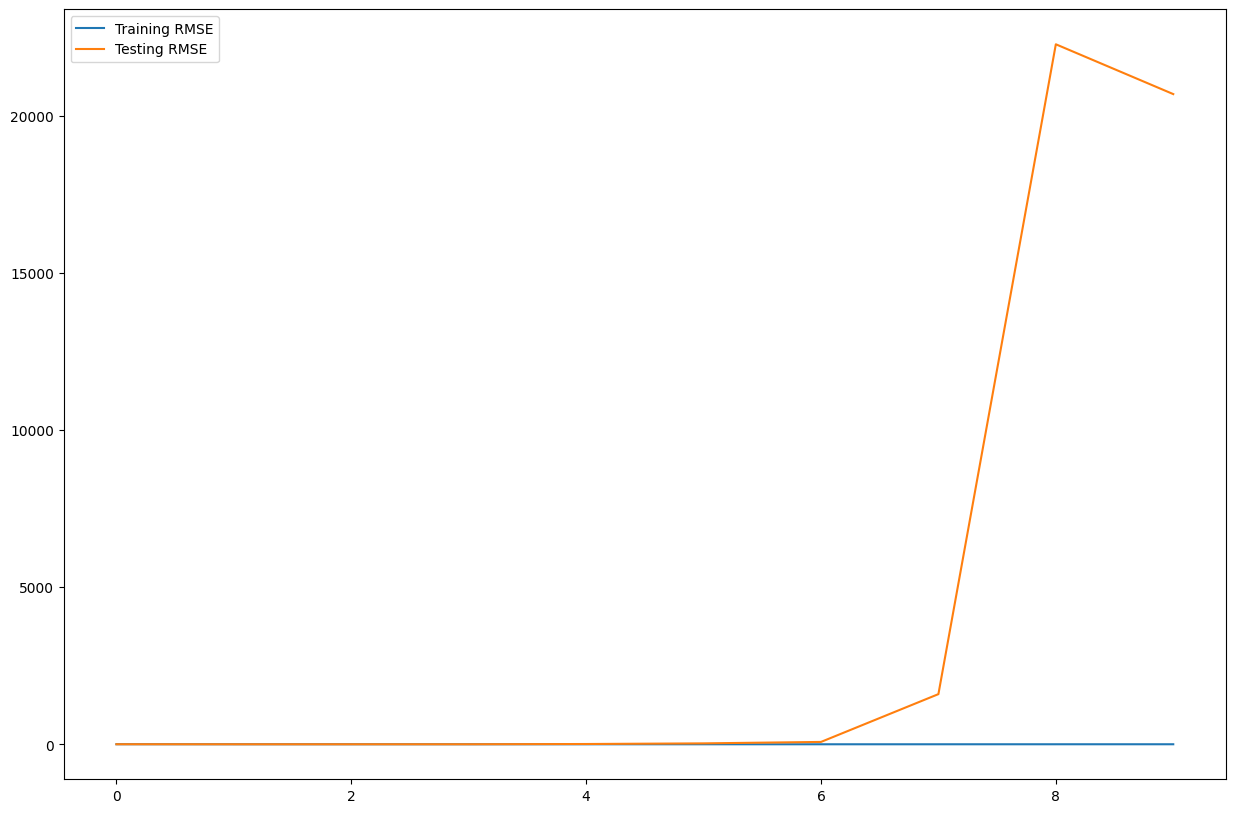

In [44]:
# Plotting Training and testing RMSE to find Optimal Degree of Polynomial for Our Model:

plt.figure(figsize=(15,10))

plt.plot(training_rmse, label= "Training RMSE")
plt.plot(testing_rmse, label= "Testing RMSE")

plt.legend()
plt.show()

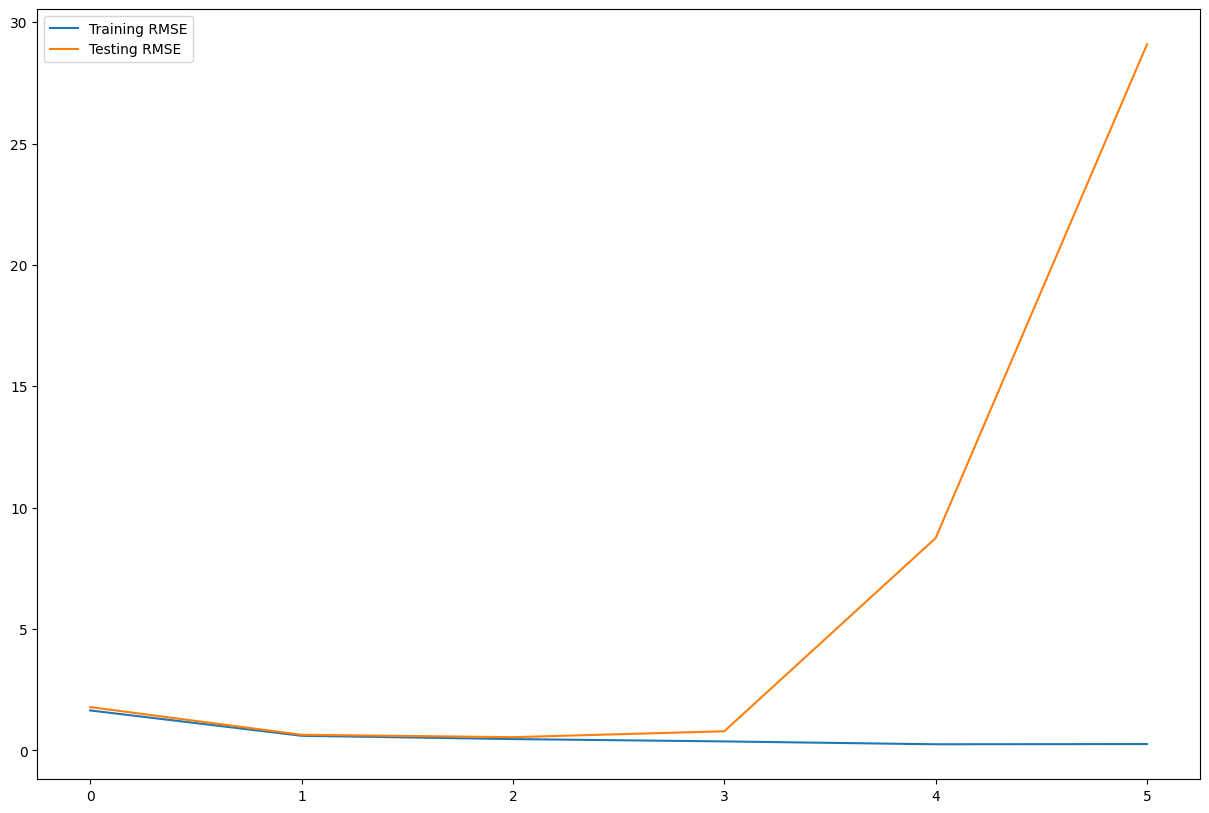

In [45]:
# Zooming in The Graph to Find Out Optimal Degrees for polynomial Model:

plt.figure(figsize=(15,10))

plt.plot(training_rmse[:6], label= "Training RMSE")
plt.plot(testing_rmse[:6], label= "Testing RMSE")

plt.legend()
plt.show()

- As we can see, Lines of Training and Testing RMSE crosses at degree value 2 and are very close at degree value of 3.

- So, 2 or 3 is ideal degree of polynomial for our model.